# K-평균 군집화(k-Means Clustering)

- **K-평균 군집화(K-Means Clustering)**
  - 정답(라벨)이 없는 데이터들을 특성에 따라 유사한 K개의 그룹(클러스터)으로 묶어주는
  - 대표적인 비지도 학습(Unsupervised Learning) 알고리즘

- 머신러닝 비지도 학습에 속한다.
- 데이터를 K 개의 군집(Cluster)으로 묶는(Clusting) 알고리즘이다.
- 각 군집의 평균(mean)을 활용하여 K 개의 군집으로 묶는다는 의미다.
- 여기서 평균(Means)이란 각 클러스터의 중심과 데이터들의 평균 거리를 의미한다.

### 알고리즘 설명
  - k-평균 군집화 알고리즘은 5가지 단계로 실행된다.
  
 1. K 개의 임의의 중심점(centroid)을 배치한다.
 2. 각 데이터들을 가장 가까운 중심점으로 할당해서 군집을 형성한다.
 3. 각 군집으로 지정된 데이터들을 기반으로 해당 군집의 중심점의 위치를 업데이트한다.
 4. 더이상 중심점의 위치가 움직이지 않을 때까지 2번, 3번 단계를 반복한다.

- kaggle의 Mall Customers Clustering Analysis 데이터를 사용해서 군집화를 실행하는 과정을 확인한다.

In [136]:
import numpy as np
import pandas as pd

# Mall_Customers.csv 을 검색해서 연결할 것.
customers = pd.read_csv('https://raw.githubusercontent.com/arienugroho050396/Mall-Customer-Segmentation-Unsupervised-ML/refs/heads/main/Mall_Customers.csv')
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


- 캐글 Mall Customer Segmentation(쇼핑몰 고객 세분화) 데이터셋

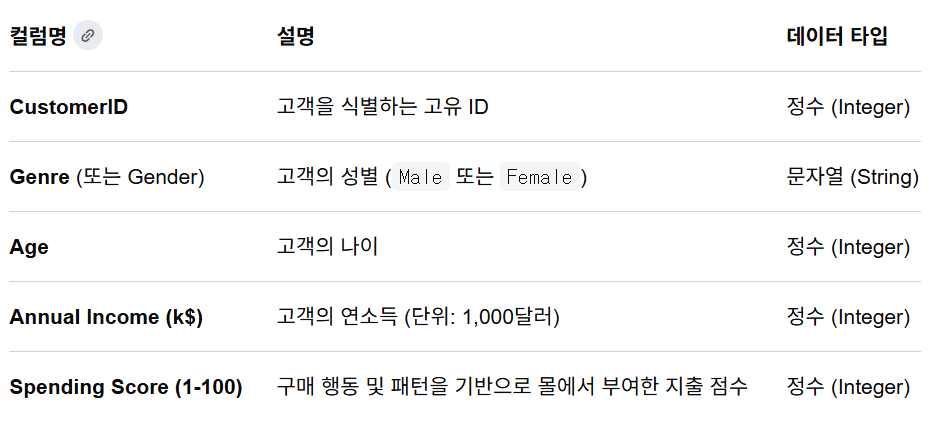

- 컬럼 추출
  - “Annual Income” 컬럼과 “Spending Score” 컬럼만 추출

In [137]:
df = customers[['Annual Income (k$)', 'Spending Score (1-100)']]
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


- 스케일링
  - k-평균 군집화는 데이터 사이의 거리를 사용하는 알고리즘이므로 스케일링을 한다.

In [138]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler()
df = sc.fit_transform(df)
df[:10]

array([[0.        , 0.3877551 ],
       [0.        , 0.81632653],
       [0.00819672, 0.05102041],
       [0.00819672, 0.7755102 ],
       [0.01639344, 0.39795918],
       [0.01639344, 0.76530612],
       [0.02459016, 0.05102041],
       [0.02459016, 0.94897959],
       [0.03278689, 0.02040816],
       [0.03278689, 0.7244898 ]])

- 알고리즘 학습

In [139]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(df)

KMeans(n_clusters=3)

- 예측

In [140]:
df = pd.DataFrame( df , columns=["Annual Income (k$)", "Spending Score (1-100)"] )

- 1. 스케일링 수행 (NumPy 배열 반환)
scaled_array = sc.fit_transform(df)

- 2. 원래 컬럼명을 사용하여 DataFrame으로 재구성
df = pd.DataFrame(
    scaled_array, columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

In [141]:
pred = model.predict(df)
df['label'] = pred
pred[:30]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 0], dtype=int32)

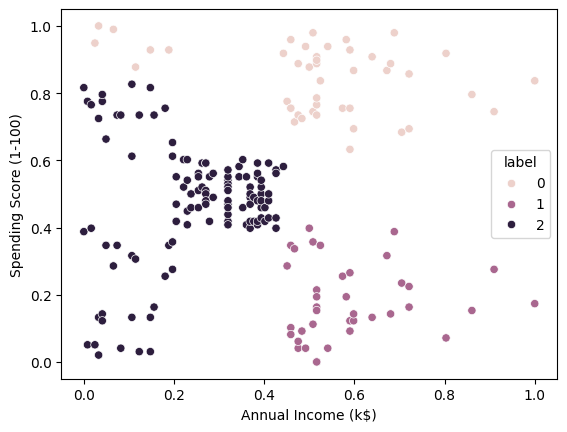

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='label')
plt.show()

- 엘보우 메소드(Elbow Method)
  - k값을 변경하면서 각 군집의 응집도를 저장한다.

  - 비지도 학습인 K-평균 군집화(K-Means Clustering)에서 가장 적절한 군집의 수(K)를 결정할 때 사용하는 **시각적 방법**

In [143]:
inertia = []
for i in range(1,10):
  model = KMeans(n_clusters= i, init = 'random',random_state=42)
  model.fit(df)
  inertia.append(model.inertia_)

- 저장한 inertia(응집도) 값을 시각화 한다.
  - 엘보우 위치의 값이 가장 적당한 군집의 개수로 판단할 수 있다.

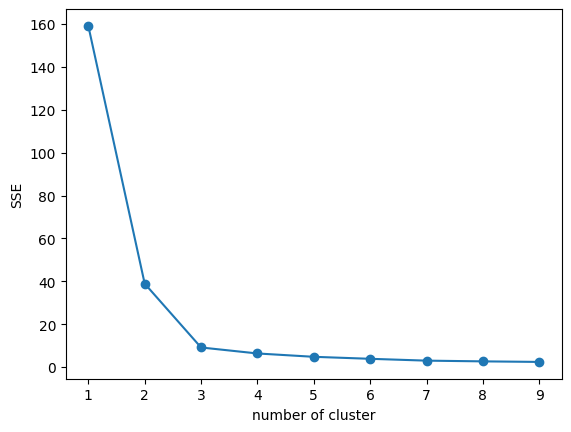

In [144]:
plt.subplots()
plt.plot(range(1,10),inertia,marker = 'o')
plt.xlabel("number of cluster")
plt.ylabel("SSE")
plt.show()

### K-Means 알고리즘을 활용하여 쇼핑몰 고객을 군집화

In [145]:
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    'CustomerID': range(1, 11),
    'Genre': ['Male', 'Female', 'Female', 'Female', 'Male', 'Female', 'Female', 'Female', 'Male', 'Female'],
    'Age': [19, 21, 20, 23, 31, 22, 35, 23, 64, 30],
    'Annual Income (k$)': [15, 15, 16, 16, 17, 17, 18, 18, 19, 19],
    'Spending Score (1-100)': [39, 81, 6, 77, 40, 76, 6, 94, 3, 72]
})

- 데이터 전처리 및 특성 선택

In [146]:
# 분석에 사용할 핵심 특성 선택 (연소득과 지출 점수)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 거리 기반 알고리즘인 K-Means를 위해 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


- 최적의 군집 수(K) 찾기 (엘보우 방법)

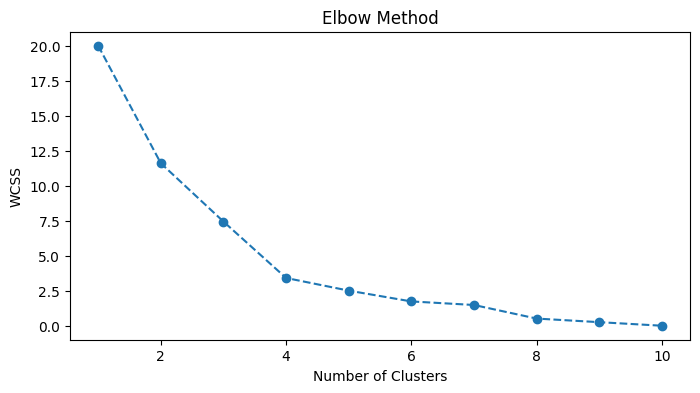

In [147]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 엘보우 그래프 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


- K-Means 모델 학습 및 예측

In [148]:
# 최적의 군집 수(K=5)로 모델 생성 및 학습
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # 각 데이터의 군집 할당

# 군집 결과 확인
print(df.head())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2  Female   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5    Male   31                  17                      40   

   Cluster  
0        4  
1        0  
2        2  
3        0  
4        2  


- 군집 결과 시각화

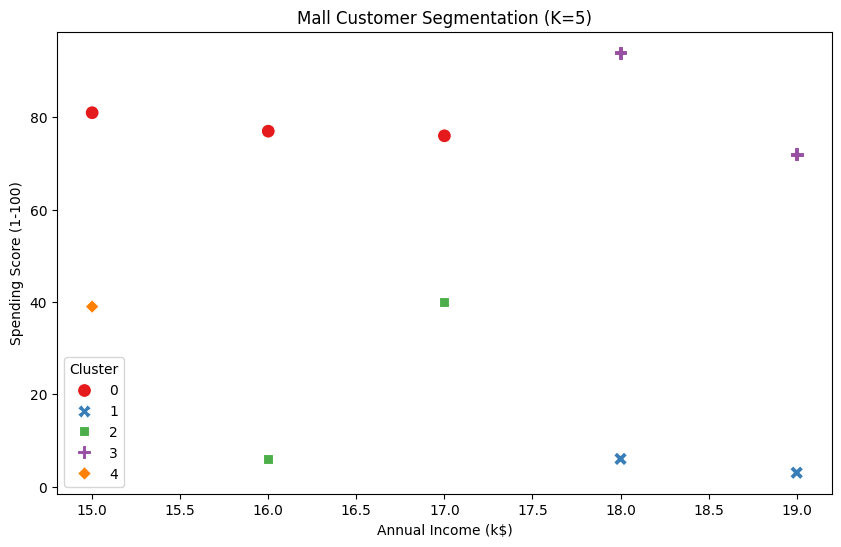

In [149]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    data=df,
    s=100,
    style='Cluster'
)
plt.title('Mall Customer Segmentation (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()


- **대표적인 5개 고객 군집 해석**

  - Cluster 0: 소득은 낮지만 지출 점수가 높은 고객 (잠재적 충성 고객)
  - Cluster 1: 소득도 높고 지출 점수도 높은 고객 (핵심 타겟 타겟)
  - Cluster 2: 소득은 낮고 지출 점수도 낮은 고객 (절약형 고객)
  - Cluster 3: 소득은 높지만 지출 점수가 낮은 고객 (신중한 자산가)
  - Cluster 4: 소득과 지출 모두 평균 수준인 고객 (일반 대중)

# 차원 축소

In [150]:
from sklearn import datasets
import pandas as pd
iris = datasets.load_iris()
dfX = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dfY = pd.DataFrame(data=iris.target, columns=['species'])
df = pd.concat([dfX,dfY], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [151]:
from sklearn.preprocessing import StandardScaler
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [152]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X2 = pca.fit_transform(X)
df = pd.DataFrame(data=X2, columns = ['PC_1', 'PC_2'])
df.head()

,PC_1,PC_2
0,-2.684126,0.319397
1,-2.714142,-0.177001
2,-2.888991,-0.144949
3,-2.745343,-0.318299
4,-2.728717,0.326755


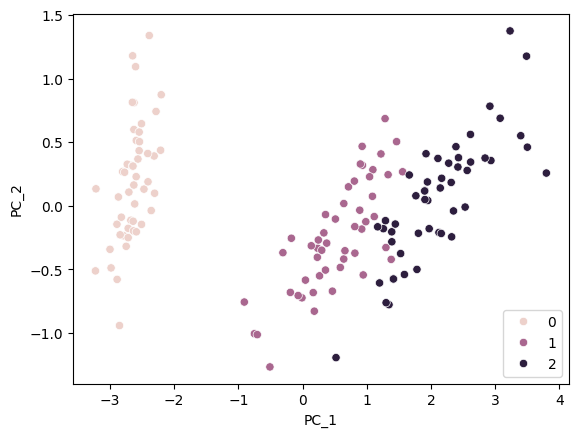

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(x=df['PC_1'], y=df['PC_2'], hue=y.values)
plt.show()

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
X_train, X_test, y_train, y_test = train_test_split(X, y,
 test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [155]:
from sklearn.metrics import *
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(precision_score(y_true, y_pred, average='macro')))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred, average='macro')))
y_pred = model.predict(X_test)
print_scores(y_test, y_pred)

accuracy_score: 1.0000
precision_score: 1.0000
recall_score: 1.0000


# 선형회귀

In [156]:
import pandas as pd
manhattan = pd.read_csv('https://raw.githubusercontent.com/Codecademy/datasets/refs/heads/master/streeteasy/manhattan.csv')
manhattan.head()

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,1545,2550,0.0,1,480,9,2.0,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,2472,11500,2.0,2,2000,4,1.0,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan
2,2919,4500,1.0,1,916,2,51.0,29,0,1,0,1,1,1,0,0,Midtown,Manhattan
3,2790,4795,1.0,1,975,3,8.0,31,0,0,0,1,1,1,0,1,Greenwich Village,Manhattan
4,3946,17500,2.0,2,4800,3,4.0,136,0,0,0,1,1,1,0,1,Soho,Manhattan


In [157]:
manhattan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_id         3539 non-null   int64  
 1   rent              3539 non-null   int64  
 2   bedrooms          3539 non-null   float64
 3   bathrooms         3539 non-null   int64  
 4   size_sqft         3539 non-null   int64  
 5   min_to_subway     3539 non-null   int64  
 6   floor             3539 non-null   float64
 7   building_age_yrs  3539 non-null   int64  
 8   no_fee            3539 non-null   int64  
 9   has_roofdeck      3539 non-null   int64  
 10  has_washer_dryer  3539 non-null   int64  
 11  has_doorman       3539 non-null   int64  
 12  has_elevator      3539 non-null   int64  
 13  has_dishwasher    3539 non-null   int64  
 14  has_patio         3539 non-null   int64  
 15  has_gym           3539 non-null   int64  
 16  neighborhood      3539 non-null   object 


In [158]:
manhattan = manhattan.drop(['neighborhood','borough'], axis=1)

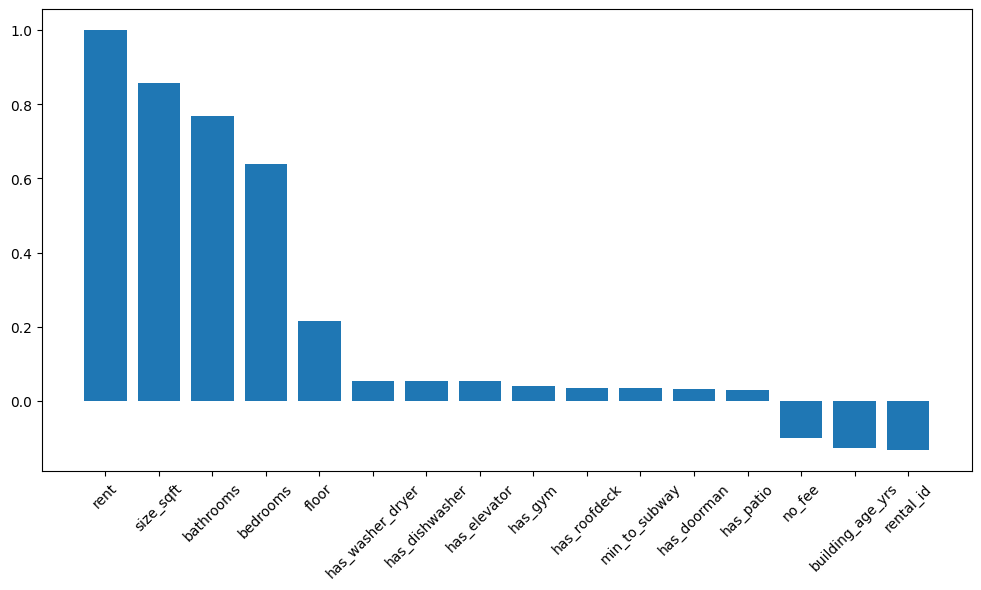

In [159]:
import matplotlib.pyplot as plt

corr_matrix = manhattan.corr()
corr_df = pd.DataFrame(corr_matrix["rent"].sort_values(ascending=False))
plt.figure(figsize=(12,6))
plt.bar(corr_df.index, corr_df["rent"])
plt.xticks(rotation=45)
plt.show()

In [160]:
X = manhattan[['size_sqft','bathrooms','bedrooms', 'floor',
'has_washer_dryer', 'has_dishwasher','has_elevator']]
y = manhattan[['rent']]

In [161]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
 test_size=0.3, random_state=42)
X_train.head()

,size_sqft,bathrooms,bedrooms,floor,has_washer_dryer,has_dishwasher,has_elevator
944,631,1,2.0,1.0,0,0,1
199,850,1,2.0,4.0,0,0,0
1457,800,1,2.0,5.0,1,1,1
2627,775,1,1.0,12.0,0,0,0
801,450,1,0.0,5.0,0,1,0


In [162]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
print('coef : ', lr.coef_)
print('intercept : ', lr.intercept_)
y_pred = lr.predict(X_test)

coef :  [[   5.01122355 1179.86269712 -339.69056329   33.14750417   79.88853766
    13.07088579   14.74563067]]
intercept :  [-1151.72616741]


In [163]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import root_mean_squared_error
# for i in range(50,501,50):
#   rf = RandomForestRegressor(random_state=42, n_estimators=i)
#   rf.fit(X_train, y_train)
#   y_pred = rf.predict(X_test)
#   result = root_mean_squared_error(y_test, y_pred)
#   print(f"hyper: {i}")
#   print(f"RMSE: {result}")


In [164]:
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error

lg = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
lg.fit(X_train, y_train)
y_pred = lg.predict(X_test)

In [165]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2score = r2_score(y_test, y_pred)
print('mse :', mse)
print('rmse :', rmse)
print('mae :', mae)
print('r2score :', r2score)

mse : 2293865.180154077
rmse : 1514.5511480811986
mae : 938.7467793415773
r2score : 0.7645106303953075


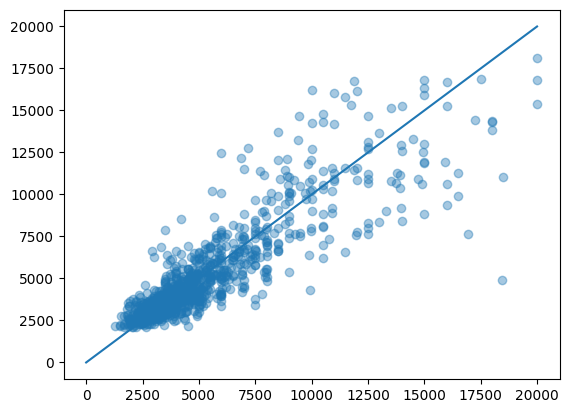

In [166]:
plt.scatter(y_test, y_pred, alpha = 0.4)
plt.plot([0, 20000], [0, 20000])
plt.show()

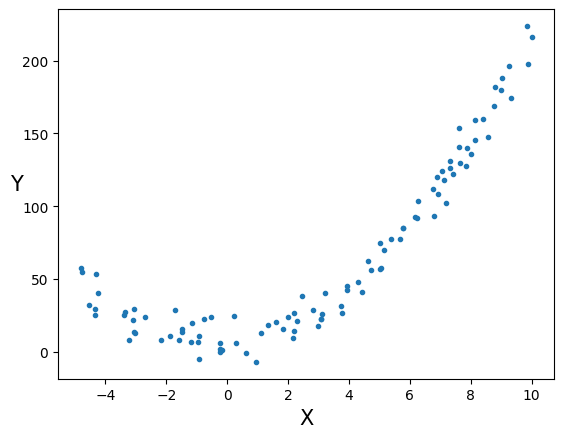

In [167]:
import numpy as np
import matplotlib.pyplot as plt

X = -5 + 15 * np.random.rand(100, 1)
noise = 10 * np.random.randn(100, 1)

y = 2*X**2 + 1*X + 10 + noise

plt.plot(X, y, ".")
plt.ylabel("Y", fontsize=15, rotation=0)
plt.xlabel("X", fontsize=15)
plt.show()

In [168]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X_poly[:10])

[[ 5.7870938  33.4904547 ]
 [ 9.88182734 97.65051159]
 [ 5.66327483 32.07268175]
 [-4.52369145 20.46378433]
 [ 5.15066831 26.52938399]
 [-1.8866052   3.55927916]
 [ 2.96603561  8.79736721]
 [ 7.60422322 57.82421074]
 [ 2.00647863  4.02595649]
 [ 3.77775642 14.27144355]]


In [169]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_poly, y)
print(lr.intercept_ , lr.coef_)

[7.46692674] [[1.29837145 1.97667974]]


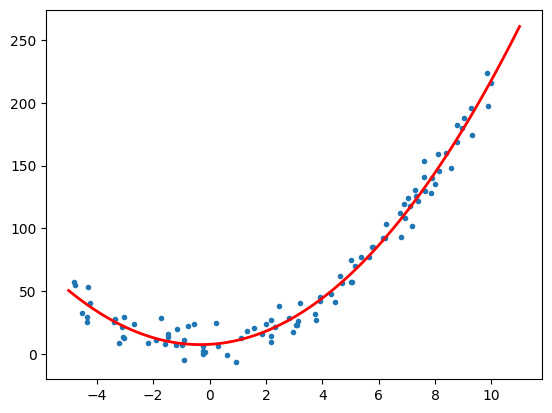

In [170]:
X_new=np.linspace(-5, 11, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.plot(X, y, ".")
plt.plot(X_new, y_new, "r", linewidth=2, label="Polynomial Predictions")
plt.show()

# 로지스틱 회귀

- 데이터가 특정 범주에 속할 확률을 0과 1 사이의 값으로 예측
- 그 확률을 기준으로 데이터를 분류하는 대표적인 지도학습 기반 머신러닝 및 통계 분류 알고리즘
- 가설함수로 사용하는 곡선 -> 시그모이드함수 또는 로지스틱 곡선이라고 함

In [172]:
import pandas as pd

diabetes = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [173]:
diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [174]:
df = diabetes.copy(deep = True)
df = df.loc[:, ['Glucose','BloodPressure','SkinThickness',
'Insulin','BMI']]

In [176]:
def iszero(x):
  return x == 0
df.apply(iszero).sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [178]:
import numpy as np
df = df.replace(0, np.nan)
df.isnull().sum(axis=0)

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [179]:
df['Glucose'].fillna(df['Glucose'].mean(),
          inplace = True)
df['BloodPressure'].fillna(df['BloodPressure'].mean(),
             inplace = True)
df['SkinThickness'].fillna(df['SkinThickness'].median(),
             inplace = True)
df['Insulin'].fillna(df['Insulin'].median(),
          inplace = True)
df['BMI'].fillna(df['BMI'].median(),
        inplace = True)
diabetes[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df
diabetes.isnull().sum(axis=0)

/tmp/ipykernel_1344/1171946991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Glucose'].fillna(df['Glucose'].mean(),
/tmp/ipykernel_1344/1171946991.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [180]:
from sklearn.model_selection import train_test_split
X = diabetes.iloc[:, :-1]
y = diabetes.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
      test_size=0.2, stratify=y, random_state=42)
print('Train : ', X_train.shape, y_train.shape)
print('Test : ', X_test.shape, y_test.shape)

Train :  (614, 8) (614,)
Test :  (154, 8) (154,)


In [181]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
y_train = y_train.values
y_test = y_test.values

In [182]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [183]:
y_pred = lr.predict(X_test)
print(y_pred[:20])

[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]


In [184]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(accuracy_score(y_true, y_pred)))
  print('precision_score:{0:.4f}'.format(precision_score(y_true, y_pred)))
  print('recall_score: {0:.4f}'.format(recall_score(y_true, y_pred)))
print_scores(y_test, y_pred)

accuracy_score: 0.7078
precision_score:0.6000
recall_score: 0.5000


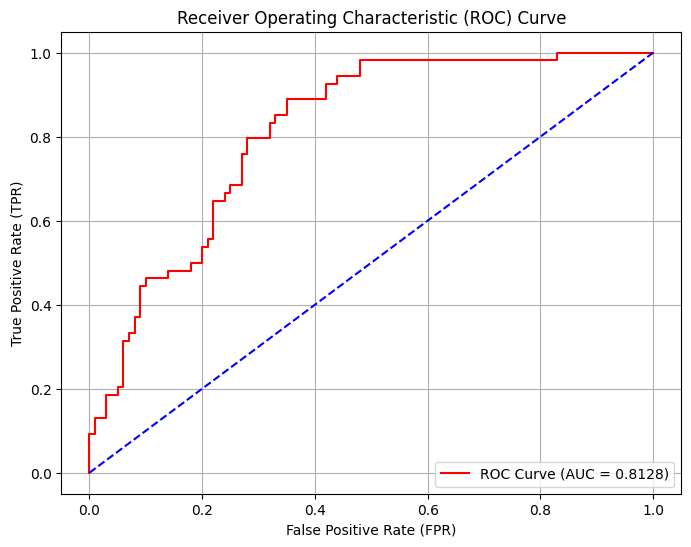

In [193]:
from sklearn.metrics import roc_curve, roc_auc_score
y_proba = lr.predict_proba(X_test)
fper, tper, thresholds = roc_curve(y_test, y_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_proba[:, 1])
def plot_roc_curve(fper, tper, auc_score):
    plt.figure(figsize=(8, 6))

    plt.plot(fper, tper, color='red', label=f'ROC Curve (AUC = {auc_score:.4f})')

    plt.plot([0, 1], [0, 1], color='blue', linestyle='--')

    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


plot_roc_curve(fper, tper, roc_auc)